In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

## Helper Classes

In [2]:
# helper
def tag_data_set_helper(row_prop):
    if row_prop <= 0.50:
        return 'train'
    elif row_prop <= 0.75:
        return 'valid'
    else:
        return 'test'

class SplitData:
    def __init__(self, str_uri_import, str_target, str_uri_export):
        self.str_uri_import = str_uri_import
        self.str_target = str_target
        self.str_uri_export = str_uri_export
    def import_data(self):
        df = pd.read_csv(self.str_uri_import)
        # dates
        for col in tqdm(['origination_date','dob']):
            df[col] = pd.to_datetime(df[col], errors='coerce')
        # sort
        df.sort_values(by='origination_date', ascending=True, inplace=True)
        # save to object
        self.df = df
    def tag_data_set(self):
        int_nrows = self.df.shape[0]
        self.df['row'] = range(1, int_nrows+1)
        self.df['row_prop'] = self.df['row'] / int_nrows
        # tag data set
        self.df['data_set'] = self.df['row_prop'].apply(tag_data_set_helper)
        # drop
        self.df.drop(['row','row_prop'], axis=1, inplace=True)
    def get_info_by_data_set(self):
        df_tmp = self.df.copy()
        df_tmp['count'] = 1
        df_tmp['min_date'] = df_tmp['origination_date']
        df_tmp['max_date'] = df_tmp['origination_date']
        dict_agg = {
            'count': 'sum',
            'min_date': 'min',
            'max_date': 'max',
            self.str_target: 'mean',
        }
        df_pivot = df_tmp.groupby(by='data_set', as_index=False).agg(dict_agg)
        df_pivot['prop_row'] = df_pivot['count'] / df_pivot['count'].sum()
        df_pivot.sort_values(by='min_date', ascending=True, inplace=True)
        # save to object
        self.df_pivot = df_pivot
    def save_df(self):
        self.df.to_csv(
            self.str_uri_export,
            index=False,
        )

## Constants

In [3]:
str_bucket = 'credit-risk-model-demo'
print(f'Bucket: {str_bucket}')

str_task = '02_split_data'
print(f'Task: {str_task}')

str_dirname_output = './output'

str_target = 'default_12m'

# data uri - import
str_filename = 'data.csv'
str_uri_import = f's3://{str_bucket}/00_data_collection/{str_filename}'

# data uri - export
str_filename = 'df.csv'
str_uri_export = f's3://{str_bucket}/{str_task}/{str_filename}'

Bucket: credit-risk-model-demo
Task: 02_split_data


## Output Directory

In [4]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

## Initialize SplitData Class

In [5]:
# init
cls_eda = SplitData(
    str_uri_import=str_uri_import,
    str_target=str_target,
    str_uri_export=str_uri_export,
)

## Import Data

In [6]:
cls_eda.import_data()

/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/fsspec/registry.py:301: UserWarning: Your installed version of s3fs is very old and known to cause
severe performance issues, see also https://github.com/dask/dask/issues/10276

To fix, you should specify a lower version bound on s3fs, or
update the current installation.

  warnings.warn(s3_msg)
100%|██████████| 2/2 [00:00<00:00, 16.92it/s]


## Out-of-Time Chronological Split

In [7]:
cls_eda.tag_data_set()

## Summary by Dataset Split

In [8]:
cls_eda.get_info_by_data_set()
cls_eda.df_pivot

,data_set,count,min_date,max_date,default_12m,prop_row
1,train,12654,2022-01-01,2023-06-27,0.189979,0.50
2,valid,6327,2023-06-27,2024-03-26,0.186660,0.25
0,test,6327,2024-03-26,2024-12-28,0.180654,0.25


## Split Summary Visualization

## Save Split Data

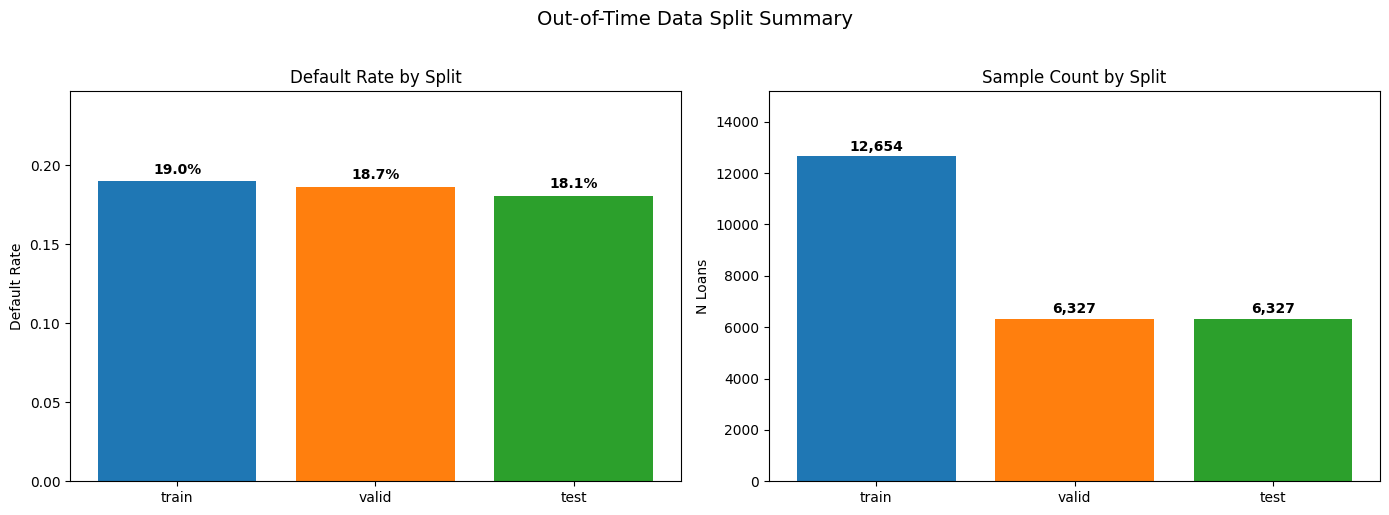

In [9]:
df_plot = cls_eda.df_pivot.copy()
df_plot.sort_values(by='min_date', ascending=True, inplace=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Out-of-Time Data Split Summary', fontsize=14, y=1.02)

# Default rate by split
bars = axes[0].bar(df_plot['data_set'], df_plot[str_target], color=['tab:blue', 'tab:orange', 'tab:green'])
axes[0].set_title('Default Rate by Split')
axes[0].set_ylabel('Default Rate')
axes[0].set_ylim(0, df_plot[str_target].max() * 1.3)
for bar, val in zip(bars, df_plot[str_target]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                 f'{val:.1%}', ha='center', va='bottom', fontweight='bold')

# Count by split
bars2 = axes[1].bar(df_plot['data_set'], df_plot['count'], color=['tab:blue', 'tab:orange', 'tab:green'])
axes[1].set_title('Sample Count by Split')
axes[1].set_ylabel('N Loans')
axes[1].set_ylim(0, df_plot['count'].max() * 1.2)
for bar, val in zip(bars2, df_plot['count']):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{str_dirname_output}/split_summary.png', bbox_inches='tight', dpi=150)
plt.show()

In [10]:
cls_eda.save_df()